# ArcFace Loss Evaluation on CelebA

This notebook evaluates ArcFace identity loss on CelebA using the FlexTok dataloader.
We compare loss distributions for same-identity pairs vs different-identity pairs.


In [2]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from flextok.utils.dataloader import create_celeb_dataloader
from flextok.model.utils.arcface_loss import ArcFaceModule


In [5]:
# Point this to the root that contains the CelebA files.
# Example layout:
# ~/data/celeba/celeba/img_align_celeba/000001.jpg
# ~/data/celeba/celeba/identity_CelebA.txt
celebA_root = Path.home() / "ml-flextok" / "data" / "celeba"

def prepare_identity_root(celeb_root: Path, prepared_root: Path) -> Path:
    """
    Prepare a root compatible with the FlexTok CelebA dataloader.
    It expects images in <root>/images and a single ID mapping file in <root>/ids/.
    """
    images_dir = prepared_root / "images"
    ids_dir = prepared_root / "ids"

    if images_dir.exists() and ids_dir.exists():
        return prepared_root

    img_align = celeb_root / "images"
    identity_file = celeb_root / "ids" / "identity_CelebA.txt"

    if not img_align.exists():
        raise FileNotFoundError(
            f"Expected images at {img_align}. Set celebA_root to the CelebA folder."
        )
    if not identity_file.exists():
        raise FileNotFoundError(
            f"Expected identity file at {identity_file}."
        )

    prepared_root.mkdir(parents=True, exist_ok=True)
    ids_dir.mkdir(parents=True, exist_ok=True)

    # Symlink images to avoid copying the dataset.
    if images_dir.exists():
        if images_dir.is_symlink() or any(images_dir.iterdir()):
            pass
        else:
            raise OSError(
                f"{images_dir} exists but is empty. Remove it or populate it with images."
            )
    else:
        try:
            images_dir.symlink_to(img_align, target_is_directory=True)
        except OSError:
            raise OSError(
                "Failed to create symlink. Create a directory at "
                f"{images_dir} containing the CelebA images instead."
            )

    ids_target = ids_dir / identity_file.name
    if not ids_target.exists():
        ids_target.write_text(identity_file.read_text())

    return prepared_root

prepared_root = celebA_root
data_root = prepare_identity_root(celebA_root, prepared_root)
print(f"Using data root: {data_root}")


Using data root: /home/iyu/ml-flextok/data/celeba


In [6]:
batch_size = 32
img_size = 256
num_workers = 4
num_batches = 20

loader = create_celeb_dataloader(
    dataset_type="celeba",
    root_dir=str(data_root),
    img_size=img_size,
    batch_size=batch_size,
    split="train",
    shuffle=True,
    num_workers=num_workers,
    return_identity=True,
    use_identity_collate=True,
)

print(f"Batches available: {len(loader)}")


Batches available: 5087


In [7]:
# ArcFace model is loaded via insightface + onnxruntime.
# Download the model if needed:
# from insightface.app import FaceAnalysis
# app = FaceAnalysis(name="buffalo_l", root="~/.insightface")
# app.prepare(ctx_id=0)

arcface = ArcFaceModule(model_name="buffalo_l", root="~/.insightface")
arcface.eval()


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
Loaded ArcFace recognition model: buffalo_l
  Model file: w600k_r50.onnx
  Input size: (112, 112)
  Embedding size: [1, 512]


ArcFaceModule()

In [8]:
def make_negative_pairs(images: torch.Tensor, identity_ids: list[str]):
    ids = np.array(identity_ids)
    indices = np.arange(len(ids))
    neg_indices = np.empty_like(indices)
    valid_mask = np.zeros_like(indices, dtype=bool)

    for i in indices:
        candidates = indices[ids != ids[i]]
        if len(candidates) == 0:
            neg_indices[i] = i
        else:
            neg_indices[i] = np.random.choice(candidates)
            valid_mask[i] = True

    return images, images[neg_indices], valid_mask

same_losses = []
diff_losses = []

for batch_idx, batch in enumerate(loader):
    if batch_idx >= num_batches:
        break

    images = batch["images"]
    identity_ids = batch["identity_ids"]
    positive_pairs = batch["positive_pairs"]
    has_pairs = batch["has_pairs"]

    if has_pairs.any():
        same_sim = arcface.compute_similarity(
            images[has_pairs],
            positive_pairs[has_pairs],
        )
        same_losses.extend((1.0 - same_sim).cpu().numpy().tolist())

    neg_a, neg_b, valid_neg = make_negative_pairs(images, identity_ids)
    if valid_neg.any():
        diff_sim = arcface.compute_similarity(neg_a[valid_neg], neg_b[valid_neg])
        diff_losses.extend((1.0 - diff_sim).cpu().numpy().tolist())

print(f"Collected {len(same_losses)} same-id losses and {len(diff_losses)} different-id losses")


Collected 2 same-id losses and 640 different-id losses


{'name': 'same_identity', 'count': 2, 'mean': 0.63671875, 'median': 0.0, 'std': 0.9316795229038993}
{'name': 'different_identity', 'count': 640, 'mean': 0.984405517578125, 'median': 0.0, 'std': 0.9998783986655546}


/tmp/ipykernel_3372450/484824348.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


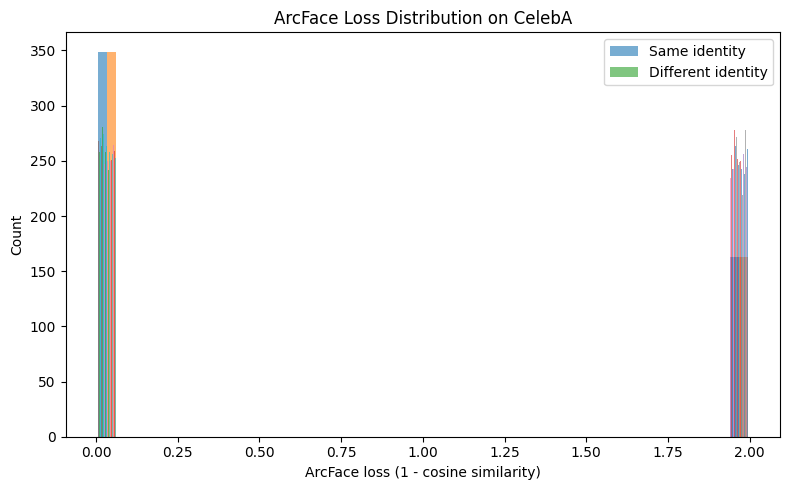

In [9]:
def summarize(values, name):
    values = np.array(values)
    return {
        "name": name,
        "count": len(values),
        "mean": float(values.mean()),
        "median": float(np.median(values)),
        "std": float(values.std()),
    }

print(summarize(same_losses, "same_identity"))
print(summarize(diff_losses, "different_identity"))

plt.figure(figsize=(8, 5))
bins = 30
plt.hist(same_losses, bins=bins, alpha=0.6, label="Same identity")
plt.hist(diff_losses, bins=bins, alpha=0.6, label="Different identity")
plt.xlabel("ArcFace loss (1 - cosine similarity)")
plt.ylabel("Count")
plt.title("ArcFace Loss Distribution on CelebA")
plt.legend()
plt.tight_layout()
plt.show()
